In [1]:
# Ejecutar en terminal o celda de Jupyter
!pip install pandas scikit-learn nltk spacy
!python -m spacy download es_core_news_sm

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.1 which is incompatible.
streamlit 1.45.1 requires pillow<12,>=7.1.0, but you have pillow 12.1.0 which is incompatible.
label-studio 1.22.0 requires numpy<3.0.0,>=2.2.6, but you have numpy 2.1.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 32.0 MB/s eta 0:00:00m eta 0:00:0136m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [1]:
import pandas as pd
import numpy as np

# Cargar datos
df = pd.read_csv('df_total.csv', encoding='UTF-8')

# Explorar datos
print("EXPLORACIÓN DE DATOS:")
print(f"Total de noticias: {len(df)}")
print(f"\nPrimeras 5 filas:")
print(df.head())

print(f"\nColumnas: {df.columns.tolist()}")

# Ver distribución de categorías
print(f"\nDistribución de categorías:")
print(df['Type'].value_counts())

# Ver ejemplo de noticia
print(f"\nEjemplo de noticia:")
print(f"Categoría: {df['Type'][0]}")
print(f"Texto: {df['news'][0][:200]}...")

EXPLORACIÓN DE DATOS:
Total de noticias: 1217

Primeras 5 filas:
                                                url  \
0  https://www.larepublica.co/redirect/post/3201905   
1  https://www.larepublica.co/redirect/post/3210288   
2  https://www.larepublica.co/redirect/post/3240676   
3  https://www.larepublica.co/redirect/post/3342889   
4  https://www.larepublica.co/redirect/post/3427208   

                                                news           Type  
0  Durante el foro La banca articulador empresari...           Otra  
1  El regulador de valores de China dijo el domin...   Regulaciones  
2  En una industria históricamente masculina como...       Alianzas  
3  Con el dato de marzo el IPC interanual encaden...  Macroeconomia  
4  Ayer en Cartagena se dio inicio a la versión n...           Otra  

Columnas: ['url', 'news', 'Type']

Distribución de categorías:
Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra 

In [2]:
from sklearn.model_selection import train_test_split

# Separar features (X) y target (y)
X = df['news']  # Texto de las noticias
y = df['Type']  # Categoría

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Mantener proporciones de categorías
)

print(f"Datos divididos:")
print(f"   Training: {len(X_train)} noticias")
print(f"   Test: {len(X_test)} noticias")

Datos divididos:
   Training: 973 noticias
   Test: 244 noticias


In [3]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear vectorizador
vectorizer = CountVectorizer(
    max_features=5000,  # Limitar a las 5000 palabras más comunes
    ngram_range=(1, 2)  # Usar palabras individuales y pares
)

# Transformar datos de entrenamiento
X_train_vec = vectorizer.fit_transform(X_train)

# Transformar datos de prueba (solo transform, NO fit)
X_test_vec = vectorizer.transform(X_test)

print(f" Vectorización completada:")
print(f"   Vocabulario: {len(vectorizer.vocabulary_)} palabras")
print(f"   Forma de X_train: {X_train_vec.shape}")

# Ver matriz (opcional)
print(f"\n📊 Ejemplo de matriz (primeras 5 noticias, primeras 10 palabras):")
X_train_dense = X_train_vec.toarray()[:5, :10]
print(X_train_dense)

 Vectorización completada:
   Vocabulario: 5000 palabras
   Forma de X_train: (973, 5000)

📊 Ejemplo de matriz (primeras 5 noticias, primeras 10 palabras):
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear y entrenar modelo
model_base = MultinomialNB()
model_base.fit(X_train_vec, y_train)

# Predecir
y_pred_base = model_base.predict(X_test_vec)

# Evaluar
accuracy_base = accuracy_score(y_test, y_pred_base)


print("VERSIÓN 1: MODELO BASE (SIN PROCESAMIENTO)")

print(f"Accuracy: {accuracy_base:.4f} ({accuracy_base*100:.2f}%)")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base))

VERSIÓN 1: MODELO BASE (SIN PROCESAMIENTO)
Accuracy: 0.8443 (84.43%)

Reporte de clasificación:
                precision    recall  f1-score   support

      Alianzas       0.85      0.80      0.82        50
    Innovacion       0.81      0.97      0.88        39
 Macroeconomia       0.97      0.90      0.93        68
          Otra       0.88      0.58      0.70        26
  Regulaciones       0.79      0.79      0.79        29
    Reputacion       0.80      0.80      0.80         5
Sostenibilidad       0.69      0.93      0.79        27

      accuracy                           0.84       244
     macro avg       0.83      0.82      0.82       244
  weighted avg       0.85      0.84      0.84       244



In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

# Descargar recursos necesarios
nltk.download('punkt')

# Crear stemmer para español
stemmer = SnowballStemmer('spanish')

def tokenize_and_stem(text):
    """
    Tokeniza y aplica stemming al texto
    """
    # Convertir a minúsculas y tokenizar
    tokens = word_tokenize(text.lower())
    
    # Aplicar stemming solo a palabras (sin signos de puntuación)
    stems = [stemmer.stem(token) for token in tokens if token.isalpha()]
    
    return ' '.join(stems)


# Aplicar stemming a todo el dataset
print("Aplicando stemming... (puede tardar un poco)")
df['news_stemmed'] = df['news'].apply(tokenize_and_stem)

print("Stemming completado")

# Ejemplo de transformación
print(f"\n📝 Ejemplo de stemming:")
print(f"Original:  {df['news'][0][:100]}...")
print(f"Stemmed:   {df['news_stemmed'][0][:100]}...")

# Dividir datos con stemming
X_stem = df['news_stemmed']
X_train_stem, X_test_stem, y_train_stem, y_test_stem = train_test_split(
    X_stem, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Vectorizar NUEVAMENTE (importante: fit de nuevo con las palabras stemmeadas)
vectorizer_stem = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_stem_vec = vectorizer_stem.fit_transform(X_train_stem)
X_test_stem_vec = vectorizer_stem.transform(X_test_stem)

# Entrenar modelo
model_stem = MultinomialNB()
model_stem.fit(X_train_stem_vec, y_train_stem)

# Evaluar
y_pred_stem = model_stem.predict(X_test_stem_vec)
accuracy_stem = accuracy_score(y_test_stem, y_pred_stem)

print("VERSIÓN 2: CON STEMMING")
print(f"Accuracy: {accuracy_stem:.4f} ({accuracy_stem*100:.2f}%)")
print(f"Mejora vs base: {(accuracy_stem - accuracy_base)*100:+.2f}%")
print(f"\n Reporte de clasificación:")
print(classification_report(y_test_stem, y_pred_stem))

[nltk_data] Downloading package punkt to /home/ciabd12/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Aplicando stemming... (puede tardar un poco)
Stemming completado

📝 Ejemplo de stemming:
Original:  Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sosten...
Stemmed:   durant el for la banc articul empresarial par el desarroll sosten el director de sostenibil y client...
VERSIÓN 2: CON STEMMING
Accuracy: 0.8525 (85.25%)
Mejora vs base: +0.82%

 Reporte de clasificación:
                precision    recall  f1-score   support

      Alianzas       0.86      0.76      0.81        50
    Innovacion       0.81      1.00      0.90        39
 Macroeconomia       0.98      0.90      0.94        68
          Otra       0.84      0.62      0.71        26
  Regulaciones       0.77      0.83      0.80        29
    Reputacion       1.00      1.00      1.00         5
Sostenibilidad       0.71      0.93      0.81        27

      accuracy                           0.85       244
     macro avg       0.86      0.86      0.85       244
  weighted avg    

In [6]:
import spacy

# Cargar modelo de español
nlp = spacy.load('es_core_news_sm')

def lemmatize_text(text):
    """
    Aplica lematización usando spaCy
    """
    # Procesar texto
    doc = nlp(text.lower())
    
    # Extraer lemas solo de palabras (sin puntuación)
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    
    return ' '.join(lemmas)


# Aplicar lematización
print("Aplicando lematización... (esto puede tardar varios minutos)")
df['news_lemma'] = df['news'].apply(lemmatize_text)

print("Lematización completada")

# Ejemplo
print(f"\nEjemplo de lematización:")
print(f"Original: {df['news'][0][:100]}...")
print(f"Lemma:    {df['news_lemma'][0][:100]}...")

# Dividir datos
X_lemma = df['news_lemma']
X_train_lemma, X_test_lemma, y_train_lemma, y_test_lemma = train_test_split(
    X_lemma, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Vectorizar
vectorizer_lemma = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_lemma_vec = vectorizer_lemma.fit_transform(X_train_lemma)
X_test_lemma_vec = vectorizer_lemma.transform(X_test_lemma)

# Entrenar
model_lemma = MultinomialNB()
model_lemma.fit(X_train_lemma_vec, y_train_lemma)

# Evaluar
y_pred_lemma = model_lemma.predict(X_test_lemma_vec)
accuracy_lemma = accuracy_score(y_test_lemma, y_pred_lemma)

print("VERSIÓN 3: CON LEMATIZACIÓN")

print(f"Accuracy: {accuracy_lemma:.4f} ({accuracy_lemma*100:.2f}%)")
print(f"Mejora vs base: {(accuracy_lemma - accuracy_base)*100:+.2f}%")
print(f"\n Reporte de clasificación:")
print(classification_report(y_test_lemma, y_pred_lemma))

Aplicando lematización... (esto puede tardar varios minutos)
Lematización completada

Ejemplo de lematización:
Original: Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sosten...
Lemma:    durante el foro el banco articulador empresarial para el desarrollo sostenible el director de sosten...
VERSIÓN 3: CON LEMATIZACIÓN
Accuracy: 0.8443 (84.43%)
Mejora vs base: +0.00%

 Reporte de clasificación:
                precision    recall  f1-score   support

      Alianzas       0.84      0.76      0.80        50
    Innovacion       0.81      0.97      0.88        39
 Macroeconomia       0.98      0.90      0.94        68
          Otra       0.84      0.62      0.71        26
  Regulaciones       0.77      0.79      0.78        29
    Reputacion       1.00      1.00      1.00         5
Sostenibilidad       0.69      0.93      0.79        27

      accuracy                           0.84       244
     macro avg       0.85      0.85      0.84     

COMPARACIÓN FINAL
Base (sin procesamiento)      : 0.8443 (84.43%)
Con Stemming                  : 0.8525 (85.25%)
Con Lematización              : 0.8443 (84.43%)


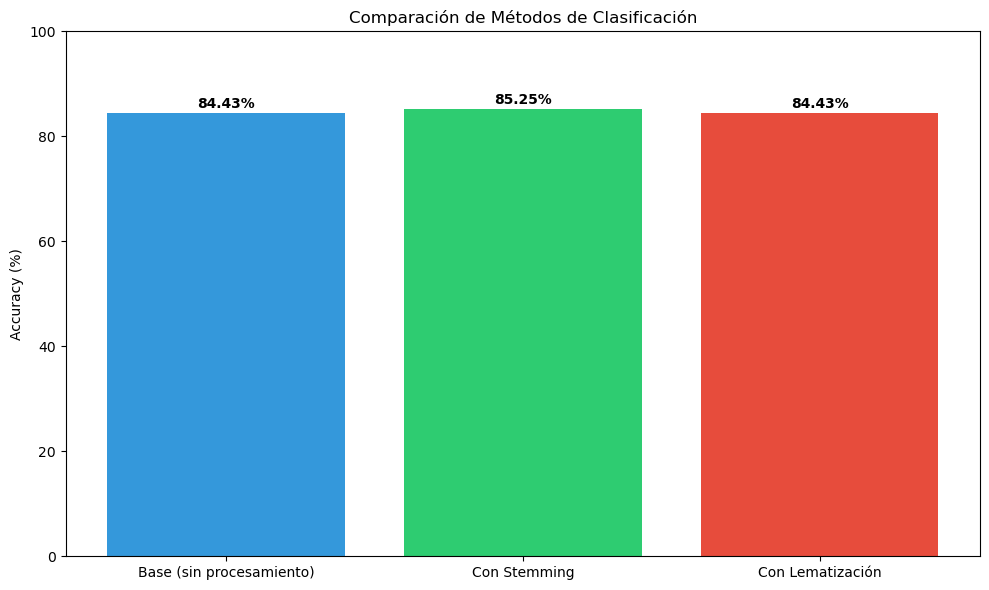


Mejor modelo: Con Stemming


In [7]:
import matplotlib.pyplot as plt

# Comparar las 3 versiones
resultados = {
    'Base (sin procesamiento)': accuracy_base,
    'Con Stemming': accuracy_stem,
    'Con Lematización': accuracy_lemma
}


print("COMPARACIÓN FINAL")

for nombre, accuracy in resultados.items():
    print(f"{nombre:30s}: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Gráfico de comparación
plt.figure(figsize=(10, 6))
plt.bar(resultados.keys(), [v*100 for v in resultados.values()], 
        color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel('Accuracy (%)')
plt.title('Comparación de Métodos de Clasificación')
plt.ylim(0, 100)
for i, (k, v) in enumerate(resultados.items()):
    plt.text(i, v*100 + 1, f'{v*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMejor modelo: {max(resultados, key=resultados.get)}")

In [8]:
def clasificar_noticia(texto, modelo='lemma'):
    """
    Clasifica una noticia nueva
    """
    # Preprocesar según el modelo elegido
    if modelo == 'base':
        texto_procesado = texto
        vec = vectorizer
        model = model_base
    elif modelo == 'stem':
        texto_procesado = tokenize_and_stem(texto)
        vec = vectorizer_stem
        model = model_stem
    else:  # lemma
        texto_procesado = lemmatize_text(texto)
        vec = vectorizer_lemma
        model = model_lemma
    
    # Vectorizar
    texto_vec = vec.transform([texto_procesado])
    
    # Predecir
    prediccion = model.predict(texto_vec)[0]
    probabilidades = model.predict_proba(texto_vec)[0]
    
    # Obtener índice de la categoría predicha
    idx_prediccion = list(model.classes_).index(prediccion)
    confianza = probabilidades[idx_prediccion]
    
    return prediccion, confianza


# Probar con noticias de ejemplo
noticias_prueba = [
    "El equipo ganó el campeonato de fútbol en el estadio",
    "El presidente anunció nuevas medidas económicas",
    "La película ganó el premio Oscar a mejor director",
    "El gobierno aprobó la nueva ley de educación"
]

print("PRUEBA CON NOTICIAS NUEVAS")

for noticia in noticias_prueba:
    categoria, confianza = clasificar_noticia(noticia, modelo='lemma')
    print(f"\nNoticia: {noticia[:60]}...")
    print(f"   Categoría: {categoria}")
    print(f"   Confianza: {confianza*100:.2f}%")

PRUEBA CON NOTICIAS NUEVAS

Noticia: El equipo ganó el campeonato de fútbol en el estadio...
   Categoría: Innovacion
   Confianza: 59.77%

Noticia: El presidente anunció nuevas medidas económicas...
   Categoría: Alianzas
   Confianza: 73.20%

Noticia: La película ganó el premio Oscar a mejor director...
   Categoría: Alianzas
   Confianza: 44.70%

Noticia: El gobierno aprobó la nueva ley de educación...
   Categoría: Regulaciones
   Confianza: 99.08%
